In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import os

In [7]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
# Unzip the dataset (only needs to be done once)
import zipfile
import os

zip_path = '/content/drive/MyDrive/AI Datasets/human_emotions_data.zip'
extract_path = '/content/human_emotions_data'

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset extracted successfully!")
else:
    print("Dataset already extracted.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset extracted successfully!


In [8]:
# Import libraries
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define parameters
img_size = (48, 48)
batch_size = 32

# Path to dataset
dataset_path = extract_path  # Now points to /content/human_emotions_data

# Data generator with train-validation split
datagen = ImageDataGenerator(
    rescale=1/255.0,
    validation_split=0.2
)

# Training data
train_gen = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    color_mode='grayscale',
    class_mode='sparse',
    batch_size=batch_size,
    subset='training',
    shuffle=True
)

# Validation data
val_gen = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    color_mode='grayscale',
    class_mode='sparse',
    batch_size=batch_size,
    subset='validation',
    shuffle=True
)

# Class names
class_names = list(train_gen.class_indices.keys())
print("Classes:", class_names)
print("Total training samples:", train_gen.samples)
print("Total validation samples:", val_gen.samples)

Found 47280 images belonging to 1 classes.
Found 11819 images belonging to 1 classes.
Classes: ['human_emotions_data']
Total training samples: 47280
Total validation samples: 11819


Batch image shape: (32, 48, 48, 1)
Batch label shape: (32,)


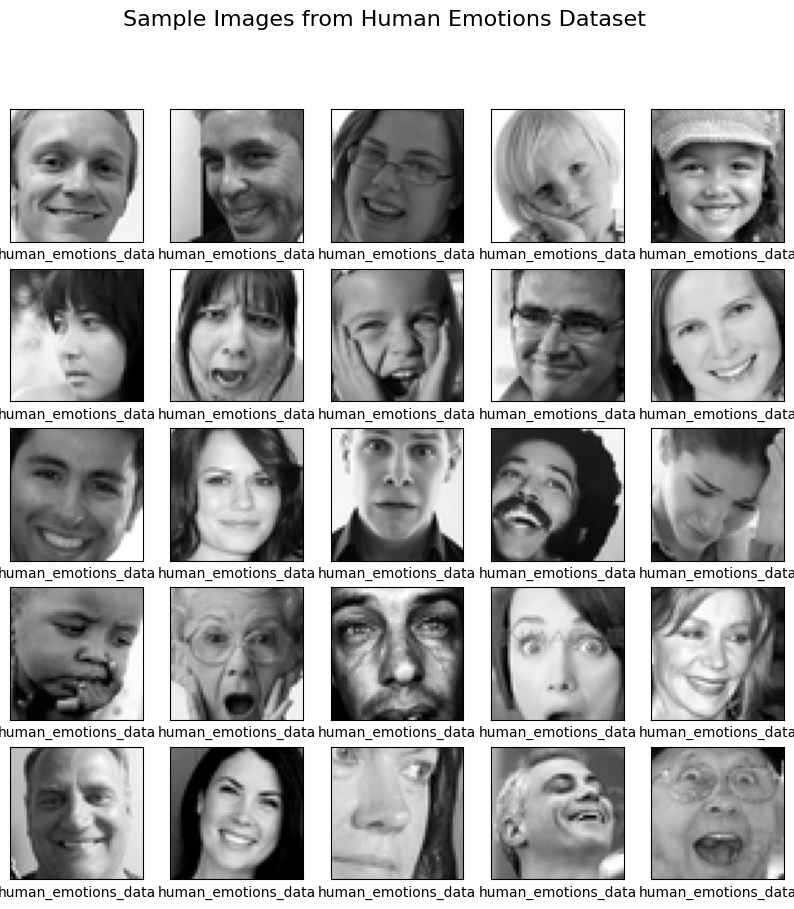

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch of training images and labels
images, labels = next(train_gen)

# Confirm the shapes
print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)

# Plot 25 sample images from the training batch
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    # Reshape grayscale image (48x48x1 → 48x48)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.xlabel(class_names[int(labels[i])])
plt.suptitle("Sample Images from Human Emotions Dataset", fontsize=16)
plt.show()


In [10]:
import tensorflow as tf

# Number of emotion classes
num_classes = len(class_names)

# Define the ANN model
ann_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(48, 48, 1)),  # input layer for grayscale images
    tf.keras.layers.Flatten(),                 # flatten the 48x48x1 images
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(num_classes, activation='softmax')  # output layer with softmax
])

# Compile the model
ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model summary
ann_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 623,105 (2.38 MB)

 Trainable params: 623,105 (2.38 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Train the ANN model
ann_history = ann_model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    verbose=1
)


Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


1478/1478 ━━━━━━━━━━━━━━━━━━━━ 156s 104ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 2/10
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 133s 90ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 3/10
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 140s 95ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 4/10
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 139s 94ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 5/10
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 135s 92ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 6/10
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 134s 91ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0.0000e+00 - val_loss: 0.0000e+00
Epoch 7/10
1478/1478 ━━━━━━━━━━━━━━━━━━━━ 134s 91ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00 - val_accuracy: 0

In [12]:
# Evaluate the ANN model on the validation set
ann_loss, ann_acc = ann_model.evaluate(val_gen, verbose=1)

print(f"\n✅ ANN Model Evaluation Results:")
print(f"Validation Loss     : {ann_loss:.4f}")
print(f"Validation Accuracy : {ann_acc*100:.2f}%")


370/370 ━━━━━━━━━━━━━━━━━━━━ 25s 67ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00

✅ ANN Model Evaluation Results:
Validation Loss     : 0.0000
Validation Accuracy : 0.00%


In [13]:
def plot_image(i, predictions_array, true_label, img):
    true = int(true_label[i])
    img = img[i].squeeze()  # removes channel dimension safely

    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    # Display grayscale image
    plt.imshow(img, cmap='gray')

    # Get predicted label
    pred = np.argmax(predictions_array)
    color = 'blue' if pred == true else 'red'

    plt.xlabel(
        f"{class_names[pred]} {100*np.max(predictions_array):.0f}% ({class_names[true]})",
        color=color
    )

def plot_value_array(i, predictions_array, true_label):
    true = int(true_label[i])

    plt.grid(False)
    plt.xticks(range(len(class_names)), class_names, rotation=45)
    plt.yticks([])
    bars = plt.bar(range(len(class_names)), predictions_array, color="#777777")
    plt.ylim([0, 1])

    pred = np.argmax(predictions_array)
    bars[pred].set_color('red')
    bars[true].set_color('blue')


In [14]:
# Get one batch of validation images and labels
test_images, test_labels = next(val_gen)

# Predict probabilities for the batch
ann_preds = ann_model.predict(test_images)  # already outputs probabilities

# Convert probabilities to predicted class indices
predicted_labels = np.argmax(ann_preds, axis=1)

# Optional: print first 5 predictions vs true labels
for i in range(5):
    print(f"Predicted: {class_names[predicted_labels[i]]}, True: {class_names[int(test_labels[i])]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
Predicted: human_emotions_data, True: human_emotions_data
Predicted: human_emotions_data, True: human_emotions_data
Predicted: human_emotions_data, True: human_emotions_data
Predicted: human_emotions_data, True: human_emotions_data
Predicted: human_emotions_data, True: human_emotions_data


/usr/local/lib/python3.12/dist-packages/keras/src/ops/nn.py:944: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


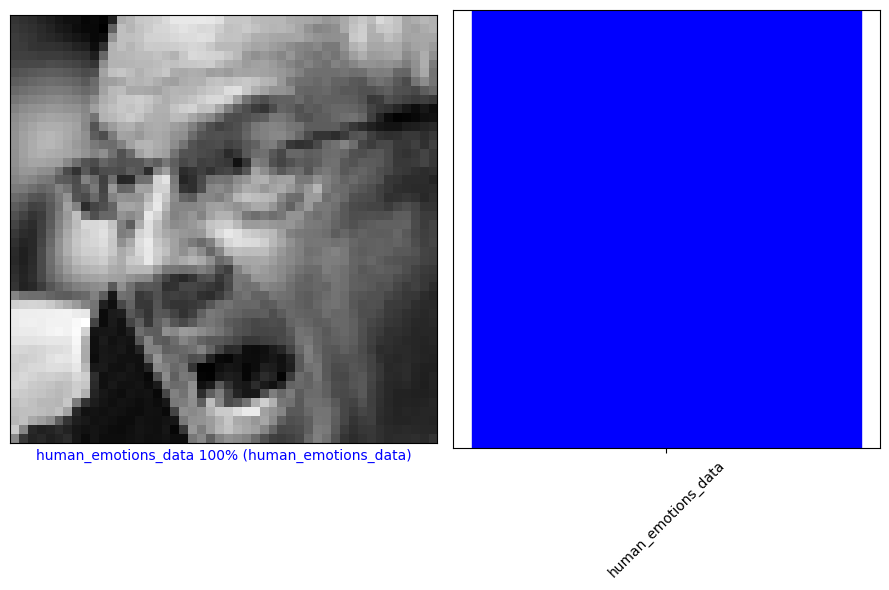

In [15]:
import matplotlib.pyplot as plt

# Choose an index from the batch
i = 20  # make sure batch size > 20

plt.figure(figsize=(9, 6))

# Display the image with predicted label
plt.subplot(1, 2, 1)
plot_image(i, ann_preds[i], test_labels, test_images)

# Display the probability bar chart
plt.subplot(1, 2, 2)
plot_value_array(i, ann_preds[i], test_labels)

plt.tight_layout()
plt.show()


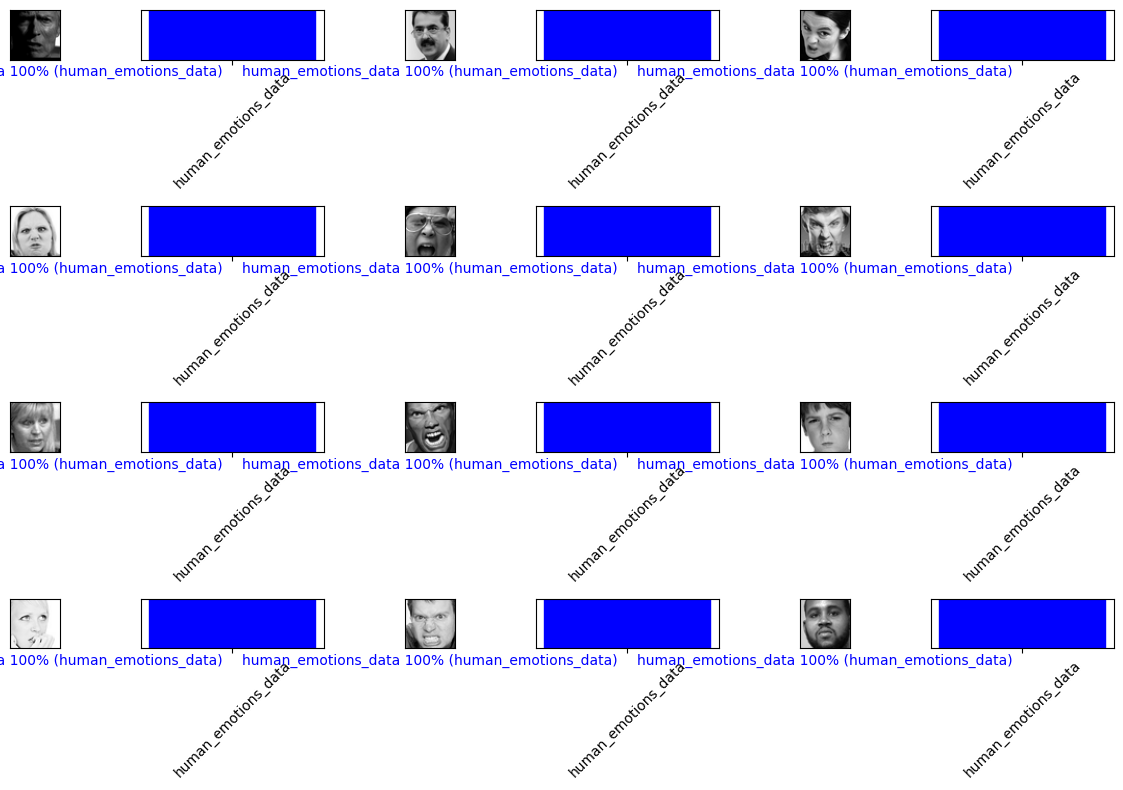

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Number of rows and columns of images to display
rows, cols = 4, 3  # displays 12 images

# Make sure your batch has at least rows*cols images
batch_size = test_images.shape[0]
num_images = min(rows*cols, batch_size)

plt.figure(figsize=(2*2*cols, 2*rows))

for i in range(num_images):
    # Plot the image
    plt.subplot(rows, 2*cols, 2*i + 1)
    plot_image(i, ann_preds[i], test_labels, test_images)

    # Plot the probability bar chart
    plt.subplot(rows, 2*cols, 2*i + 2)
    plot_value_array(i, ann_preds[i], test_labels)

plt.tight_layout()
plt.show()
